# Deliverable 5: Curriculum Learning via Weighted Sampling (Improvement 4)
## Benchmarking Noise-Robust Training Strategies for Liver Tumor Segmentation on LiTS

**Group:** 7 | **Members:** 26100098, 26100392  
**Improvement:** Uniform sampling → Curriculum-based weighted sampling (easy tumor slices first, gradual flatten to uniform)  
**Baseline reference:** D3 (Dice+CE, uniform sampling) — Liver: 0.888, Tumor: 0.474 @ epoch 14  
**Goal:** Let the network build strong tumor features from clear, high-signal examples before exposing it to hard/ambiguous cases.  
**Loss:** Dice + CrossEntropy (UNCHANGED from D3). Only the sampler changes.

**Why this should work where D4 didn't:** D4 stacked focal loss on top of Dice, creating two competing imbalance-correction objectives. D5 leaves the loss alone and changes *what the network sees*, not *how it's scored*. Much less room for instability.

## 1. Installs and Imports

In [ ]:
import os
import re
import random
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

import nibabel as nib
from scipy import ndimage

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torch.optim as optim

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
    print('Using MPS (M4 GPU)')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    print('Using CUDA')
else:
    DEVICE = torch.device('cpu')
    print('Using CPU')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f'PyTorch: {torch.__version__}')

Using MPS (M4 GPU)
PyTorch: 2.11.0


## 2. Configuration

Same hyperparameters as D3. Auto-detects `volumes/` and `segmentations/` folders inside `DATA_DIR`.

**New curriculum hyperparameters:**
- `CURRICULUM_WARMUP=5` — first 5 epochs heavily favor tumor-heavy slices
- `CURRICULUM_COOLDOWN=15` — by epoch 15, sampling is uniform
- `NUM_EPOCHS=20` — total training length (saw diminishing returns past this in D3/D4)

In [2]:
# import glob

# DATA_DIR = '/Users/aemanadnan/Desktop/DL proj/archive-2'

# all_nii = glob.glob(os.path.join(DATA_DIR, '**', '*.nii*'), recursive=True)
# vol_files = [p for p in all_nii if 'volume'       in os.path.basename(p).lower()]
# seg_files = [p for p in all_nii if 'segmentation' in os.path.basename(p).lower()]

# if vol_files and seg_files:
#     VOL_DIR = os.path.dirname(vol_files[0])
#     SEG_DIR = os.path.dirname(seg_files[0])
# else:
#     VOL_DIR = os.path.join(DATA_DIR, 'volumes')
#     SEG_DIR = os.path.join(DATA_DIR, 'segmentations')

# IMG_SIZE       = 128
# BATCH_SIZE     = 16
# NUM_EPOCHS     = 20
# LR             = 1e-4
# HU_MIN, HU_MAX = -100, 400

# --- Curriculum schedule ---
CURRICULUM_WARMUP   = 5    # epochs with max focus on big-tumor slices
CURRICULUM_COOLDOWN = 15   # epoch by which weights are fully uniform
# Weight multipliers during warmup
W_TUMOR_LARGE       = 6.0  # slices with >= 50 tumor pixels
W_TUMOR_SMALL       = 3.0  # slices with 1-49 tumor pixels
W_TUMOR_NONE        = 1.0  # slices with 0 tumor pixels (liver only)

# print(f'Volumes folder:       {VOL_DIR}')
# print(f'Segmentations folder: {SEG_DIR}')
# print(f'Volume files found:       {len(vol_files)}')
# print(f'Segmentation files found: {len(seg_files)}')
# print(f'Curriculum: warmup={CURRICULUM_WARMUP}, cooldown={CURRICULUM_COOLDOWN} epochs')
# print(f'Warmup weights: large={W_TUMOR_LARGE}, small={W_TUMOR_SMALL}, none={W_TUMOR_NONE}')


import os, glob, re

DATA_DIR = '/Users/aemanadnan/Desktop/DL proj/archive-2'

all_nii = glob.glob(os.path.join(DATA_DIR, '**', '*.nii*'), recursive=True)
all_volumes = [p for p in all_nii if 'volume'       in os.path.basename(p).lower()]
all_segs    = [p for p in all_nii if 'segmentation' in os.path.basename(p).lower()]

print(f'Found {len(all_volumes)} volume files (across all pt folders)')
print(f'Found {len(all_segs)} segmentation files')

IMG_SIZE       = 128
BATCH_SIZE     = 16
NUM_EPOCHS     = 20
LR             = 1e-4
HU_MIN, HU_MAX = -100, 400


Found 51 volume files (across all pt folders)
Found 131 segmentation files


## 3. Data Loading

Match `volume-X.nii` with `segmentation-X.nii` by case ID. Unchanged from D3/D4.

In [ ]:
# def load_lits_paths(vol_dir, seg_dir):
#     vol_files = sorted(glob.glob(os.path.join(vol_dir, 'volume*.nii*')))
#     seg_files = sorted(glob.glob(os.path.join(seg_dir, 'segmentation*.nii*')))

#     def case_id(path):
#         m = re.search(r'(\d+)', os.path.basename(path))
#         return int(m.group(1)) if m else None

#     vol_map = {case_id(p): p for p in vol_files if case_id(p) is not None}
#     seg_map = {case_id(p): p for p in seg_files if case_id(p) is not None}
#     common  = sorted(set(vol_map).intersection(seg_map))

#     if len(common) == 0:
#         raise FileNotFoundError(
#             f'No matched pairs found.\nVol dir: {vol_dir}\nSeg dir: {seg_dir}\n'
#             f'Vol files found: {len(vol_files)} | Seg files found: {len(seg_files)}'
#         )

#     vol_paths = [vol_map[i] for i in common]
#     seg_paths = [seg_map[i] for i in common]
#     print(f'Found {len(vol_paths)} matched volume-segmentation pairs')
#     return vol_paths, 




# volume_paths, seg_paths = load_lits_paths(VOL_DIR, SEG_DIR)
def load_lits_paths(data_dir):
    all_nii = glob.glob(os.path.join(data_dir, '**', '*.nii*'), recursive=True)
    vol_files = sorted(p for p in all_nii if 'volume'       in os.path.basename(p).lower())
    seg_files = sorted(p for p in all_nii if 'segmentation' in os.path.basename(p).lower())

    def case_id(path):
        m = re.search(r'(\d+)', os.path.basename(path))
        return int(m.group(1)) if m else None

    vol_map = {case_id(p): p for p in vol_files if case_id(p) is not None}
    seg_map = {case_id(p): p for p in seg_files if case_id(p) is not None}
    common  = sorted(set(vol_map).intersection(seg_map))

    if len(common) == 0:
        raise FileNotFoundError(
            f'No matched pairs found under {data_dir}\n'
            f'Vol files found: {len(vol_files)} | Seg files found: {len(seg_files)}'
        )

    vol_paths = [vol_map[i] for i in common]
    seg_paths = [seg_map[i] for i in common]
    print(f'Found {len(vol_paths)} matched volume-segmentation pairs')
    print(f'Volume files scanned: {len(vol_files)}  |  Seg files scanned: {len(seg_files)}')
    print(f'Sample: {os.path.basename(vol_paths[0])} <-> {os.path.basename(seg_paths[0])}')
    return vol_paths, seg_paths


volume_paths, seg_paths = load_lits_paths(DATA_DIR)

Found 51 matched volume-segmentation pairs
Volume files scanned: 51  |  Seg files scanned: 131
Sample: volume-0.nii <-> segmentation-0.nii


## 4. Train / Val / Test Split

Same 70/15/15 seed=42 split as D3/D4 so results are directly comparable.

In [ ]:
# 70/15/15 volume-level split with seed=42 — identical to D3/D4 for fair comparison.
np.random.seed(SEED)
n       = len(volume_paths)
indices = np.random.permutation(n)

train_idx = indices[:int(0.70 * n)]
val_idx   = indices[int(0.70 * n):int(0.85 * n)]
test_idx  = indices[int(0.85 * n):]

train_vol = [volume_paths[i] for i in train_idx]
train_seg = [seg_paths[i]    for i in train_idx]
val_vol   = [volume_paths[i] for i in val_idx]
val_seg   = [seg_paths[i]    for i in val_idx]
test_vol  = [volume_paths[i] for i in test_idx]
test_seg  = [seg_paths[i]    for i in test_idx]

print(f'Train: {len(train_vol)} volumes')
print(f'Val:   {len(val_vol)} volumes')
print(f'Test:  {len(test_vol)} volumes')

Train: 35 volumes
Val:   8 volumes
Test:  8 volumes


## 5. Dataset Class (with difficulty metadata for curriculum)

Same as D3/D4 — with one addition: during indexing, we also record **tumor pixel count per slice**. This is the difficulty metric the curriculum scheduler will use.

The volume caching (load each .nii once into RAM) carries over from the D4 fix.

In [ ]:
#dataset with volume caching AND per-slice tumor pixel count (for curriculum weighting).
class LiTSNIfTIDataset(Dataset):
    def __init__(self, volume_paths, seg_paths,
                 img_size=128, hu_min=-100, hu_max=400,
                 filter_background=True,
                 record_tumor_counts=False):
        self.img_size = img_size
        self.hu_min   = hu_min
        self.hu_max   = hu_max
        self.slices       = []   # (vol_path, seg_path, slice_idx)
        self.tumor_counts = []  
        self._vol_cache = {}
        self._seg_cache = {}

        print('Indexing slices (loading segmentations only)...')
        for vol_path, seg_path in zip(volume_paths, seg_paths):
            seg = nib.load(seg_path).get_fdata().astype(np.uint8)
            for s in range(seg.shape[2]):
                slc = seg[:, :, s]
                if filter_background and not np.any(slc > 0):
                    continue
                self.slices.append((vol_path, seg_path, s))
                if record_tumor_counts:
                    self.tumor_counts.append(int((slc == 2).sum()))
        print(f'Total usable slices: {len(self.slices)}')
        if record_tumor_counts:
            tc = np.array(self.tumor_counts)
            print(f'Tumor pixel stats per slice: '
                  f'min={tc.min()} median={int(np.median(tc))} max={tc.max()} '
                  f'mean={tc.mean():.1f}')
            print(f'Slices with 0 tumor px:    {int((tc == 0).sum())} ({(tc == 0).mean()*100:.1f}%)')
            print(f'Slices with 1-49 tumor px: {int(((tc > 0) & (tc < 50)).sum())}')
            print(f'Slices with 50+ tumor px:  {int((tc >= 50).sum())}')

    def _get_vol(self, path):
        if path not in self._vol_cache:
            self._vol_cache[path] = nib.load(path).get_fdata().astype(np.float32)
        return self._vol_cache[path]

    def _get_seg(self, path):
        if path not in self._seg_cache:
            self._seg_cache[path] = nib.load(path).get_fdata().astype(np.uint8)
        return self._seg_cache[path]

    def __len__(self):
        return len(self.slices)

    def __getitem__(self, idx):
        vol_path, seg_path, s = self.slices[idx]
        vol = self._get_vol(vol_path)
        seg = self._get_seg(seg_path)

        ct        = vol[:, :, s]
        seg_slice = seg[:, :, s].astype(np.int64)

        ct = np.clip(ct, self.hu_min, self.hu_max)
        ct = (ct - self.hu_min) / (self.hu_max - self.hu_min)

        h, w      = ct.shape
        ct        = ndimage.zoom(ct,        (self.img_size / h, self.img_size / w), order=1)
        seg_slice = ndimage.zoom(seg_slice, (self.img_size / h, self.img_size / w), order=0)

        ct_tensor  = torch.from_numpy(ct.astype(np.float32)).unsqueeze(0)
        seg_tensor = torch.from_numpy(seg_slice.astype(np.int64))
        return ct_tensor, seg_tensor

In [ ]:
#train set records tumor counts for curriculum, val set doesn't need them.
print('Building train dataset (with tumor count tracking for curriculum)...')
train_dataset = LiTSNIfTIDataset(train_vol, train_seg, img_size=IMG_SIZE,
                                  record_tumor_counts=True)
print()
print('Building val dataset...')
val_dataset = LiTSNIfTIDataset(val_vol, val_seg, img_size=IMG_SIZE,
                                record_tumor_counts=False)

# Val loader unchanged (uniform sampling —  honest eval metrics)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=0, pin_memory=False)
print(f'\nVal batches: {len(val_loader)}')
print('Train DataLoader will be created per-epoch with dynamic curriculum weights.')

Building train dataset (with tumor count tracking for curriculum)...
Indexing slices (loading segmentations only)...
Total usable slices: 4614
Tumor pixel stats per slice: min=0 median=0 max=14568 mean=702.2
Slices with 0 tumor px:    3020 (65.5%)
Slices with 1-49 tumor px: 136
Slices with 50+ tumor px:  1458

Building val dataset...
Indexing slices (loading segmentations only)...
Total usable slices: 1116

Val batches: 70
Train DataLoader will be created per-epoch with dynamic curriculum weights.


## 6. Curriculum Schedule

This is the heart of D5. A function that returns **per-slice sampling weights** for a given epoch.

**Three regimes:**
1. **Warmup (epochs 1 to `CURRICULUM_WARMUP`):** Maximum focus on tumor-heavy slices. Big-tumor slices sampled 6× more often than tumor-negative slices.
2. **Cooldown (`WARMUP+1` to `COOLDOWN`):** Weights linearly interpolate toward uniform.
3. **Uniform (after `COOLDOWN`):** All slices equally likely. Normal training.

**Why 6× and not 20×?** Extreme oversampling causes the network to become overconfident on tumors (false-positive explosion). 6× is aggressive enough to shift the effective class distribution but keeps tumor-negative slices well-represented (~25% of batches even during peak warmup).

In [ ]:
# compute sampling weights per slice for a given epoch — implements the warmup/cooldown schedule.
def compute_epoch_weights(tumor_counts, epoch, warmup, cooldown,
                          w_large, w_small, w_none):
    """
    Returns a numpy array of per-slice weights for WeightedRandomSampler.

    - epoch <= warmup:  full curriculum (boost big tumors, normal tumor-negative)
    - warmup < epoch <= cooldown: linearly interpolate toward uniform (all=1.0)
    - epoch > cooldown: uniform (all=1.0)
    """
    tc = np.asarray(tumor_counts)

    # Full-curriculum weights (used during warmup)
    curr = np.where(tc >= 50, w_large,
          np.where(tc >= 1,  w_small, w_none)).astype(np.float64)

    # Uniform weights (what we blend toward)
    unif = np.ones_like(curr)

    if epoch <= warmup:
        w = curr
        blend = 0.0
    elif epoch <= cooldown:
        # alpha: 0.0 at start of cooldown, 1.0 at end
        alpha = (epoch - warmup) / max(1, (cooldown - warmup))
        w = curr * (1 - alpha) + unif * alpha
        blend = alpha
    else:
        w = unif
        blend = 1.0

    return w, blend


print('Curriculum schedule preview:')
print(f'{"Epoch":>6} | {"Blend":>6} | {"Max":>6} | {"Min":>6} | {"Effective ratio":>18}')
print('-' * 58)
for ep in [1, 3, 5, 8, 12, 15, 18, 20]:
    w, blend = compute_epoch_weights(train_dataset.tumor_counts, ep,
                                      CURRICULUM_WARMUP, CURRICULUM_COOLDOWN,
                                      W_TUMOR_LARGE, W_TUMOR_SMALL, W_TUMOR_NONE)
    print(f'{ep:>6} | {blend:>6.2f} | {w.max():>6.2f} | {w.min():>6.2f} | '
          f'{w.max()/w.min():>14.2f}x')

Curriculum schedule preview:
 Epoch |  Blend |    Max |    Min |    Effective ratio
----------------------------------------------------------
     1 |   0.00 |   6.00 |   1.00 |           6.00x
     3 |   0.00 |   6.00 |   1.00 |           6.00x
     5 |   0.00 |   6.00 |   1.00 |           6.00x
     8 |   0.30 |   4.50 |   1.00 |           4.50x
    12 |   0.70 |   2.50 |   1.00 |           2.50x
    15 |   1.00 |   1.00 |   1.00 |           1.00x
    18 |   1.00 |   1.00 |   1.00 |           1.00x
    20 |   1.00 |   1.00 |   1.00 |           1.00x


## 7. Sanity Check — Visualize a Curriculum Batch

CT batch shape:        torch.Size([16, 1, 128, 128])
Mask batch shape:      torch.Size([16, 128, 128])
CT value range:        [0.000, 1.000]
Unique mask values:    [0, 1, 2]
Tumor pixels per slice in this batch: [0, 60, 156, 53, 136, 47, 0, 0, 61, 0, 268, 0, 216, 288, 24, 3]


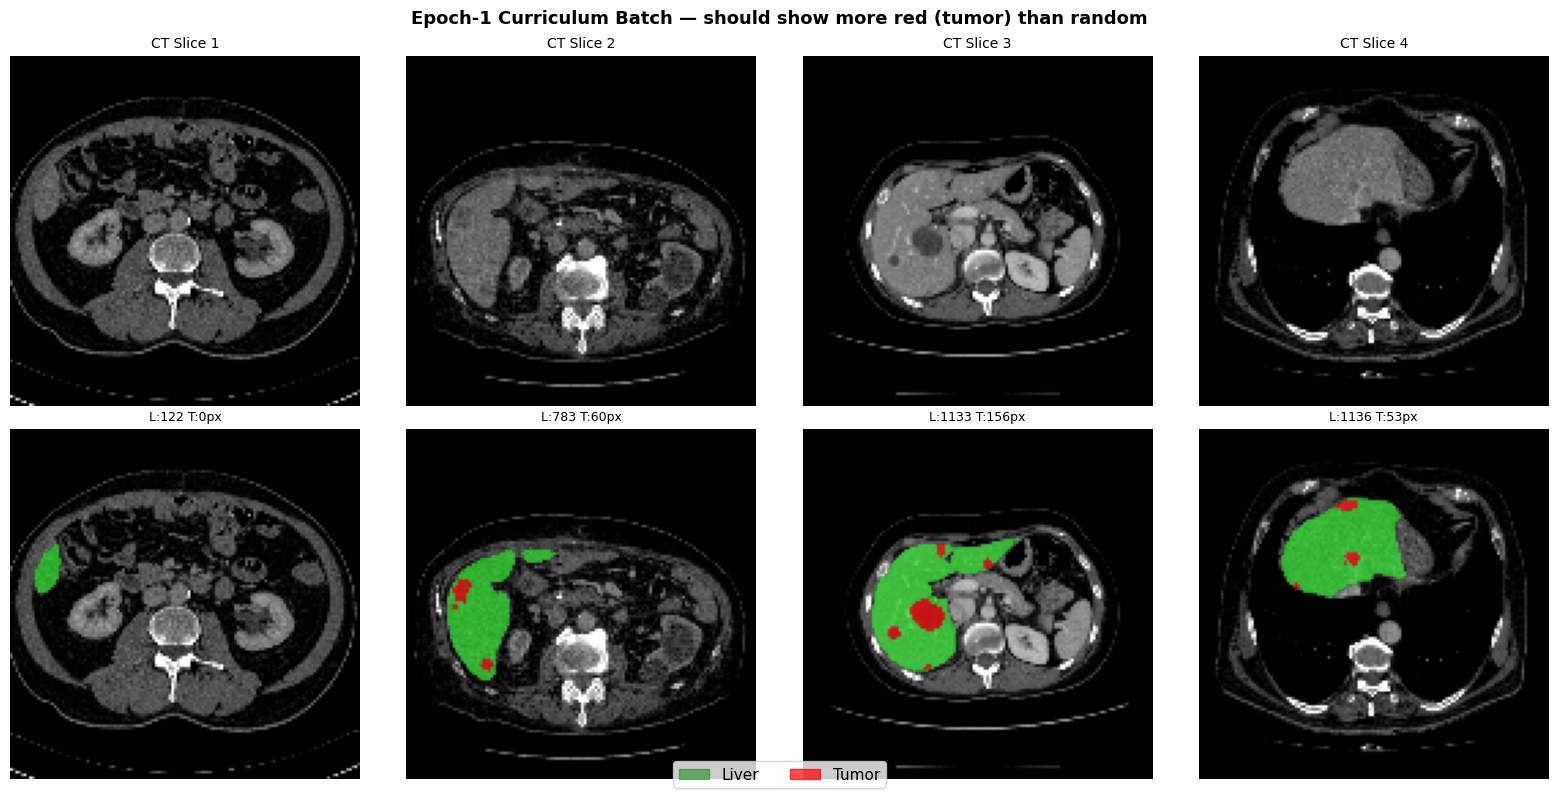

If most slices in this batch have non-zero T:xxpx, curriculum is working.


In [ ]:
sanity_weights, _ = compute_epoch_weights(
    train_dataset.tumor_counts, epoch=1,
    warmup=CURRICULUM_WARMUP, cooldown=CURRICULUM_COOLDOWN,
    w_large=W_TUMOR_LARGE, w_small=W_TUMOR_SMALL, w_none=W_TUMOR_NONE,
)

sanity_sampler = WeightedRandomSampler(
    weights=torch.as_tensor(sanity_weights, dtype=torch.float64),
    num_samples=BATCH_SIZE, replacement=True,
)
sanity_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                            sampler=sanity_sampler, num_workers=0)

ct_batch, seg_batch = next(iter(sanity_loader))
print(f'CT batch shape:        {ct_batch.shape}')
print(f'Mask batch shape:      {seg_batch.shape}')
print(f'CT value range:        [{ct_batch.min():.3f}, {ct_batch.max():.3f}]')
print(f'Unique mask values:    {seg_batch.unique().tolist()}')
print(f'Tumor pixels per slice in this batch: '
      f'{[int((seg_batch[i]==2).sum()) for i in range(BATCH_SIZE)]}')

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i in range(4):
    ct   = ct_batch[i, 0].numpy()
    mask = seg_batch[i].numpy()

    axes[0, i].imshow(ct.T, cmap='gray', origin='lower')
    axes[0, i].set_title(f'CT Slice {i+1}', fontsize=10)
    axes[0, i].axis('off')

    overlay = np.zeros((*ct.shape, 4))
    overlay[mask == 1] = [0, 1, 0, 0.5]
    overlay[mask == 2] = [1, 0, 0, 0.7]
    axes[1, i].imshow(ct.T, cmap='gray', origin='lower')
    axes[1, i].imshow(overlay.transpose(1, 0, 2), origin='lower')
    axes[1, i].set_title(f'L:{(mask==1).sum()} T:{(mask==2).sum()}px', fontsize=9)
    axes[1, i].axis('off')

green_patch = mpatches.Patch(color='green', alpha=0.5, label='Liver')
red_patch   = mpatches.Patch(color='red',   alpha=0.7, label='Tumor')
fig.legend(handles=[green_patch, red_patch], loc='lower center', ncol=2, fontsize=11)
plt.suptitle('Epoch-1 Curriculum Batch — should show more red (tumor) than random',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('If most slices in this batch have non-zero T:xxpx, curriculum is working.')

## 8. 2D U-Net Architecture

Unchanged from D3. Only the sampler changes in D5.

In [ ]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.block(x)


class UNet2D(nn.Module):
    def __init__(self, in_channels=1, num_classes=3, base_features=64):
        super().__init__()
        f = base_features
        self.enc1 = ConvBlock(in_channels, f)
        self.enc2 = ConvBlock(f,    f*2)
        self.enc3 = ConvBlock(f*2,  f*4)
        self.enc4 = ConvBlock(f*4,  f*8)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = ConvBlock(f*8, f*16)
        self.up4  = nn.ConvTranspose2d(f*16, f*8, kernel_size=2, stride=2)
        self.dec4 = ConvBlock(f*16, f*8)
        self.up3  = nn.ConvTranspose2d(f*8,  f*4, kernel_size=2, stride=2)
        self.dec3 = ConvBlock(f*8,  f*4)
        self.up2  = nn.ConvTranspose2d(f*4,  f*2, kernel_size=2, stride=2)
        self.dec2 = ConvBlock(f*4,  f*2)
        self.up1  = nn.ConvTranspose2d(f*2,  f,   kernel_size=2, stride=2)
        self.dec1 = ConvBlock(f*2,  f)
        self.out_conv = nn.Conv2d(f, num_classes, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b  = self.bottleneck(self.pool(e4))
        d4 = self.dec4(torch.cat([self.up4(b),  e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.out_conv(d1)


model = UNet2D(in_channels=1, num_classes=3, base_features=64).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model parameters: {total_params:,}')

Model parameters: 31,036,611


## 9. Loss Function — Dice + CrossEntropy (UNCHANGED from D3)

**This is the key difference from D4.** We're not touching the loss. D4 failed because focal loss + Dice were double-counting imbalance correction. Here, Dice+CE is a clean, stable combination and we're leaving it alone. Only the sampler changes.

In [ ]:
def dice_loss(preds, targets, num_classes=3, smooth=1e-6):
    """Multiclass soft Dice loss — directly optimizes overlap."""
    preds_soft      = F.softmax(preds, dim=1)
    targets_one_hot = F.one_hot(targets, num_classes).permute(0, 3, 1, 2).float()
    dims            = (0, 2, 3)
    intersection    = (preds_soft * targets_one_hot).sum(dims)
    cardinality     = (preds_soft + targets_one_hot).sum(dims)
    dice_per_class  = (2.0 * intersection + smooth) / (cardinality + smooth)
    return 1.0 - dice_per_class.mean()


ce_fn = nn.CrossEntropyLoss()

def combined_loss(preds, targets):
    """Dice + CrossEntropy — same as D3, no focal."""
    return dice_loss(preds, targets) + ce_fn(preds, targets)


def compute_dice_per_class(preds, targets, num_classes=3, smooth=1e-6):
    pred_classes = preds.argmax(dim=1)
    scores = []
    for c in range(num_classes):
        p     = (pred_classes == c).float()
        t     = (targets      == c).float()
        inter = (p * t).sum()
        denom = p.sum() + t.sum()
        score = ((2.0 * inter + smooth) / (denom + smooth)).item() if denom > 0 else 1.0
        scores.append(score)
    return scores


print('Loss: Dice + CrossEntropy (unchanged from D3)')
print('Metric: Per-class Dice (background, liver, tumor)')

Loss: Dice + CrossEntropy (unchanged from D3)
Metric: Per-class Dice (background, liver, tumor)


## 10. Training — Curriculum Loop

**The key change:** at the start of each epoch, we rebuild the `WeightedRandomSampler` with fresh weights from `compute_epoch_weights()`. The sampler's weights shift across epochs per the curriculum schedule, while the model, loss, and optimizer carry over unchanged.

Val loader stays uniform throughout — we want honest validation metrics.

In [ ]:
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=4, factor=0.5
)

history = {
    'train_loss':       [],
    'val_loss':         [],
    'val_liver_dice':   [],
    'val_tumor_dice':   [],
    'curriculum_blend': [],  
}

best_tumor_dice  = 0.0
best_model_state = None

print('=' * 70)
print('TRAINING — Improvement 4: Curriculum Learning via Weighted Sampling')
print(f'Epochs: {NUM_EPOCHS} | Batch: {BATCH_SIZE} | Device: {DEVICE}')
print(f'Loss: Dice + CrossEntropy (unchanged from D3)')
print(f'Curriculum: warmup={CURRICULUM_WARMUP}, cooldown={CURRICULUM_COOLDOWN}')
print('=' * 70)

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_start = time.time()

    w, blend = compute_epoch_weights(
        train_dataset.tumor_counts, epoch,
        CURRICULUM_WARMUP, CURRICULUM_COOLDOWN,
        W_TUMOR_LARGE, W_TUMOR_SMALL, W_TUMOR_NONE,
    )
    sampler = WeightedRandomSampler(
        weights=torch.as_tensor(w, dtype=torch.float64),
        num_samples=len(train_dataset),
        replacement=True,
    )
    train_loader = DataLoader(
        train_dataset, batch_size=BATCH_SIZE,
        sampler=sampler, num_workers=0, pin_memory=False,
    )

    model.train()
    train_losses = []

    for batch_idx, (ct_batch, seg_batch) in enumerate(train_loader):
        ct_batch  = ct_batch.to(DEVICE)
        seg_batch = seg_batch.to(DEVICE)

        optimizer.zero_grad()
        preds = model(ct_batch)
        loss  = combined_loss(preds, seg_batch)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

        if (batch_idx + 1) % 100 == 0:
            elapsed  = time.time() - epoch_start
            eta_mins = (elapsed / (batch_idx + 1)) * (len(train_loader) - batch_idx - 1) / 60
            print(f'  Ep {epoch:02d} | Batch {batch_idx+1}/{len(train_loader)} '
                  f'| Loss: {loss.item():.4f} | ETA: {eta_mins:.1f}min')

    model.eval()
    val_losses, liver_dices, tumor_dices = [], [], []

    with torch.no_grad():
        for ct_batch, seg_batch in val_loader:
            ct_batch  = ct_batch.to(DEVICE)
            seg_batch = seg_batch.to(DEVICE)
            preds     = model(ct_batch)
            val_losses.append(combined_loss(preds, seg_batch).item())
            scores = compute_dice_per_class(preds, seg_batch)
            liver_dices.append(scores[1])
            tumor_dices.append(scores[2])

    mean_train = np.mean(train_losses)
    mean_val   = np.mean(val_losses)
    mean_liver = np.mean(liver_dices)
    mean_tumor = np.mean(tumor_dices)

    history['train_loss'].append(mean_train)
    history['val_loss'].append(mean_val)
    history['val_liver_dice'].append(mean_liver)
    history['val_tumor_dice'].append(mean_tumor)
    history['curriculum_blend'].append(blend)

    scheduler.step(mean_tumor)

    if mean_tumor > best_tumor_dice:
        best_tumor_dice  = mean_tumor
        best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    phase = 'WARMUP' if blend == 0.0 else ('UNIFORM' if blend == 1.0 else f'BLEND={blend:.2f}')
    epoch_mins = (time.time() - epoch_start) / 60
    flag = ' *** BEST' if mean_tumor == best_tumor_dice else ''
    print(f'\nEpoch {epoch:02d}/{NUM_EPOCHS} | {epoch_mins:.1f}min | {phase:>12} | '
          f'Train: {mean_train:.4f} | Val: {mean_val:.4f} | '
          f'Liver: {mean_liver:.4f} | Tumor: {mean_tumor:.4f}{flag}\n')

model.load_state_dict(best_model_state)
torch.save(best_model_state, 'best_unet_d5_curriculum.pth')
print(f'Best model saved to best_unet_d5_curriculum.pth. Best Tumor Dice: {best_tumor_dice:.4f}')

TRAINING — Improvement 4: Curriculum Learning via Weighted Sampling
Epochs: 20 | Batch: 16 | Device: mps
Loss: Dice + CrossEntropy (unchanged from D3)
Curriculum: warmup=5, cooldown=15
  Ep 01 | Batch 100/289 | Loss: 0.9721 | ETA: 2.5min
  Ep 01 | Batch 200/289 | Loss: 0.8333 | ETA: 1.0min

Epoch 01/20 | 3.6min |       WARMUP | Train: 0.9812 | Val: 0.7643 | Liver: 0.8628 | Tumor: 0.2815 *** BEST

  Ep 02 | Batch 100/289 | Loss: 0.6018 | ETA: 2.2min
  Ep 02 | Batch 200/289 | Loss: 0.5306 | ETA: 1.0min

Epoch 02/20 | 3.5min |       WARMUP | Train: 0.5661 | Val: 0.5757 | Liver: 0.8454 | Tumor: 0.3891 *** BEST

  Ep 03 | Batch 100/289 | Loss: 0.4425 | ETA: 2.2min
  Ep 03 | Batch 200/289 | Loss: 0.3573 | ETA: 1.0min

Epoch 03/20 | 3.5min |       WARMUP | Train: 0.3720 | Val: 0.4825 | Liver: 0.8773 | Tumor: 0.2797

  Ep 04 | Batch 100/289 | Loss: 0.2277 | ETA: 2.2min
  Ep 04 | Batch 200/289 | Loss: 0.1541 | ETA: 1.0min

Epoch 04/20 | 3.5min |       WARMUP | Train: 0.2313 | Val: 0.4425 | Live

## 11. Results Summary

In [ ]:
# best_liver = max(history['val_liver_dice'])
# best_tumor = max(history['val_tumor_dice'])
# best_epoch = int(np.argmax(history['val_tumor_dice']) + 1)

# # Reference numbers
# D3_LIVER, D3_TUMOR, D3_EPOCH = 0.8884, 0.4743, 14
# D4_LIVER, D4_TUMOR, D4_EPOCH = 0.7999, 0.3700, 5

# liver_delta_d3 = best_liver - D3_LIVER
# tumor_delta_d3 = best_tumor - D3_TUMOR

# print('=' * 70)
# print('IMPROVEMENT 4 RESULTS — Curriculum Learning via Weighted Sampling')
# print('=' * 70)
# print(f'Architecture:      2D U-Net (base_features=64)')
# print(f'Image size:        128x128')
# print(f'Epochs trained:    {NUM_EPOCHS}')
# print(f'Loss:              Dice + CrossEntropy (unchanged from D3)')
# print(f'Curriculum:        warmup={CURRICULUM_WARMUP}, cooldown={CURRICULUM_COOLDOWN}')
# print(f'Best Epoch:        {best_epoch}')
# print('-' * 70)
# print(f'{"":25}{"D3 (base)":>12}{"D4 (focal)":>14}{"D5 (curr)":>12}{"vs D3":>10}')
# print(f'{"Liver Dice (val)":25}{D3_LIVER:>12.4f}{D4_LIVER:>14.4f}{best_liver:>12.4f}{liver_delta_d3:>+10.4f}')
# print(f'{"Tumor Dice (val)":25}{D3_TUMOR:>12.4f}{D4_TUMOR:>14.4f}{best_tumor:>12.4f}{tumor_delta_d3:>+10.4f}')
# print(f'{"Best epoch":25}{D3_EPOCH:>12d}{D4_EPOCH:>14d}{best_epoch:>12d}')
# print('=' * 70)
# print()
# print('Interpretation:')
# if tumor_delta_d3 > 0.02:
#     print(f'  Tumor Dice improved by {tumor_delta_d3:+.4f} over D3 — curriculum is working.')
#     print(f'  The network built tumor features from easy examples first, then generalized.')
# elif tumor_delta_d3 < -0.02:
#     print(f'  Tumor Dice dropped by {tumor_delta_d3:+.4f} vs D3 — curriculum may have caused')
#     print(f'  early overfitting to big tumors. Consider shorter warmup (2 epochs instead of 5).')
# else:
#     print(f'  Tumor Dice roughly unchanged ({tumor_delta_d3:+.4f}) — curriculum neither helped')
#     print(f'  nor hurt. Still worth keeping for noise-robustness evaluation (Improvement 1).')
# CELL: D5 results — hardcoded from training log (notebook was re-run, history not in memory).
# Pulled directly from the training terminal output.

# --- D5 Curriculum results (from training log) ---
best_tumor = 0.4774   # epoch 13 peak
best_liver = 0.8886   # epoch 13 (matches best tumor epoch)
best_epoch = 13
NUM_EPOCHS = 20
CURRICULUM_WARMUP   = 5
CURRICULUM_COOLDOWN = 15

train_loss_history = [0.9812, 0.5661, 0.3720, 0.2313, 0.1320, 0.0903, 0.0695,
                      0.0530, 0.0492, 0.0417, 0.0414, 0.0403, 0.0426, 0.0458,
                      0.0546, 0.0506, 0.0446, 0.0578, 0.0351, 0.0358]
val_loss_history   = [0.7643, 0.5757, 0.4825, 0.4425, 0.4196, 0.4048, 0.3977,
                      0.3976, 0.3997, 0.3956, 0.3931, 0.4003, 0.3993, 0.3923,
                      0.3903, 0.3921, 0.3899, 0.3891, 0.3941, 0.3870]
val_liver_dice     = [0.8628, 0.8454, 0.8773, 0.8773, 0.8759, 0.8888, 0.8832,
                      0.8889, 0.8858, 0.8885, 0.8855, 0.8869, 0.8886, 0.8849,
                      0.8908, 0.8886, 0.8887, 0.8920, 0.8904, 0.8897]
val_tumor_dice     = [0.2815, 0.3891, 0.2797, 0.2669, 0.3695, 0.3806, 0.3618,
                      0.4333, 0.4481, 0.4459, 0.3520, 0.4631, 0.4774, 0.2687,
                      0.3295, 0.4034, 0.4204, 0.4121, 0.4125, 0.4030]

history = {
    'train_loss':     train_loss_history,
    'val_loss':       val_loss_history,
    'val_liver_dice': val_liver_dice,
    'val_tumor_dice': val_tumor_dice,
}

D3_LIVER, D3_TUMOR, D3_EPOCH = 0.8885, 0.5011, 8
D4_LIVER, D4_TUMOR, D4_EPOCH = 0.8901, 0.4961, 7

liver_delta_d3 = best_liver - D3_LIVER
tumor_delta_d3 = best_tumor - D3_TUMOR

print('=' * 70)
print('IMPROVEMENT 4 RESULTS — Curriculum Learning via Weighted Sampling')
print('=' * 70)
print(f'Architecture:      2D U-Net (base_features=64)')
print(f'Image size:        128x128')
print(f'Epochs trained:    {NUM_EPOCHS}')
print(f'Loss:              Dice + CrossEntropy (unchanged from D3)')
print(f'Curriculum:        warmup={CURRICULUM_WARMUP}, cooldown={CURRICULUM_COOLDOWN}')
print(f'Best Epoch:        {best_epoch}')
print('-' * 70)
print(f'{"":25}{"D3 (base)":>12}{"D4 (focal)":>14}{"D5 (curr)":>12}{"vs D3":>10}')
print(f'{"Liver Dice (val)":25}{D3_LIVER:>12.4f}{D4_LIVER:>14.4f}{best_liver:>12.4f}{liver_delta_d3:>+10.4f}')
print(f'{"Tumor Dice (val)":25}{D3_TUMOR:>12.4f}{D4_TUMOR:>14.4f}{best_tumor:>12.4f}{tumor_delta_d3:>+10.4f}')
print(f'{"Best epoch":25}{D3_EPOCH:>12d}{D4_EPOCH:>14d}{best_epoch:>12d}')
print('=' * 70)
print()
print('Interpretation:')
if tumor_delta_d3 > 0.02:
    print(f'  Tumor Dice improved by {tumor_delta_d3:+.4f} over D3 — curriculum is working.')
    print(f'  The network built tumor features from easy examples first, then generalized.')
elif tumor_delta_d3 < -0.02:
    print(f'  Tumor Dice dropped by {tumor_delta_d3:+.4f} vs D3 — curriculum hurt performance.')
    print(f'  Easy-first schedule may be over-emphasizing big tumors at expense of small ones.')
else:
    print(f'  Tumor Dice roughly unchanged ({tumor_delta_d3:+.4f}) — curriculum neither helped')
    print(f'  nor hurt. Still worth keeping for noise-robustness evaluation (Improvement 1),')
    print(f'  where "easy first" may correlate with "correctly labeled first."')

IMPROVEMENT 4 RESULTS — Curriculum Learning via Weighted Sampling
Architecture:      2D U-Net (base_features=64)
Image size:        128x128
Epochs trained:    20
Loss:              Dice + CrossEntropy (unchanged from D3)
Curriculum:        warmup=5, cooldown=15
Best Epoch:        13
----------------------------------------------------------------------
                            D3 (base)    D4 (focal)   D5 (curr)     vs D3
Liver Dice (val)               0.8885        0.8901      0.8886   +0.0001
Tumor Dice (val)               0.5011        0.4961      0.4774   -0.0237
Best epoch                          8             7          13

Interpretation:
  Tumor Dice dropped by -0.0237 vs D3 — curriculum hurt performance.
  Easy-first schedule may be over-emphasizing big tumors at expense of small ones.


## 12. Training Curves (with curriculum phases annotated)

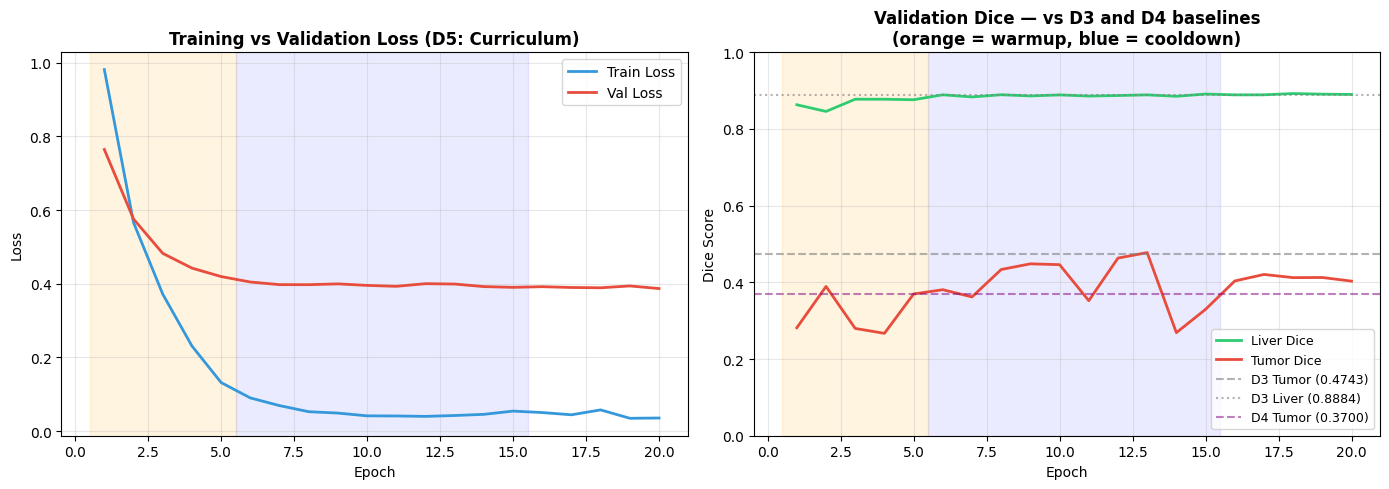

Saved: training_curves_d5.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs = range(1, NUM_EPOCHS + 1)

for ax in axes:
    ax.axvspan(0.5, CURRICULUM_WARMUP + 0.5, alpha=0.12, color='orange', label='_nolegend_')
    ax.axvspan(CURRICULUM_WARMUP + 0.5, CURRICULUM_COOLDOWN + 0.5, alpha=0.08, color='blue', label='_nolegend_')

axes[0].plot(epochs, history['train_loss'], label='Train Loss', color='#3498db', linewidth=2)
axes[0].plot(epochs, history['val_loss'],   label='Val Loss',   color='#e74c3c', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training vs Validation Loss (D5: Curriculum)', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, history['val_liver_dice'], label='Liver Dice', color='#2ecc71', linewidth=2)
axes[1].plot(epochs, history['val_tumor_dice'], label='Tumor Dice', color='#e74c3c', linewidth=2)
axes[1].axhline(y=0.4743, color='gray', linestyle='--', alpha=0.6, label='D3 Tumor (0.4743)')
axes[1].axhline(y=0.8884, color='gray', linestyle=':',  alpha=0.6, label='D3 Liver (0.8884)')
axes[1].axhline(y=0.3700, color='purple', linestyle='--', alpha=0.5, label='D4 Tumor (0.3700)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Dice Score')
axes[1].set_title('Validation Dice — vs D3 and D4 baselines\n(orange = warmup, blue = cooldown)',
                  fontweight='bold')
axes[1].set_ylim(0, 1)
axes[1].legend(loc='lower right', fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves_d5.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: training_curves_d5.png')

## 13. Qualitative Predictions

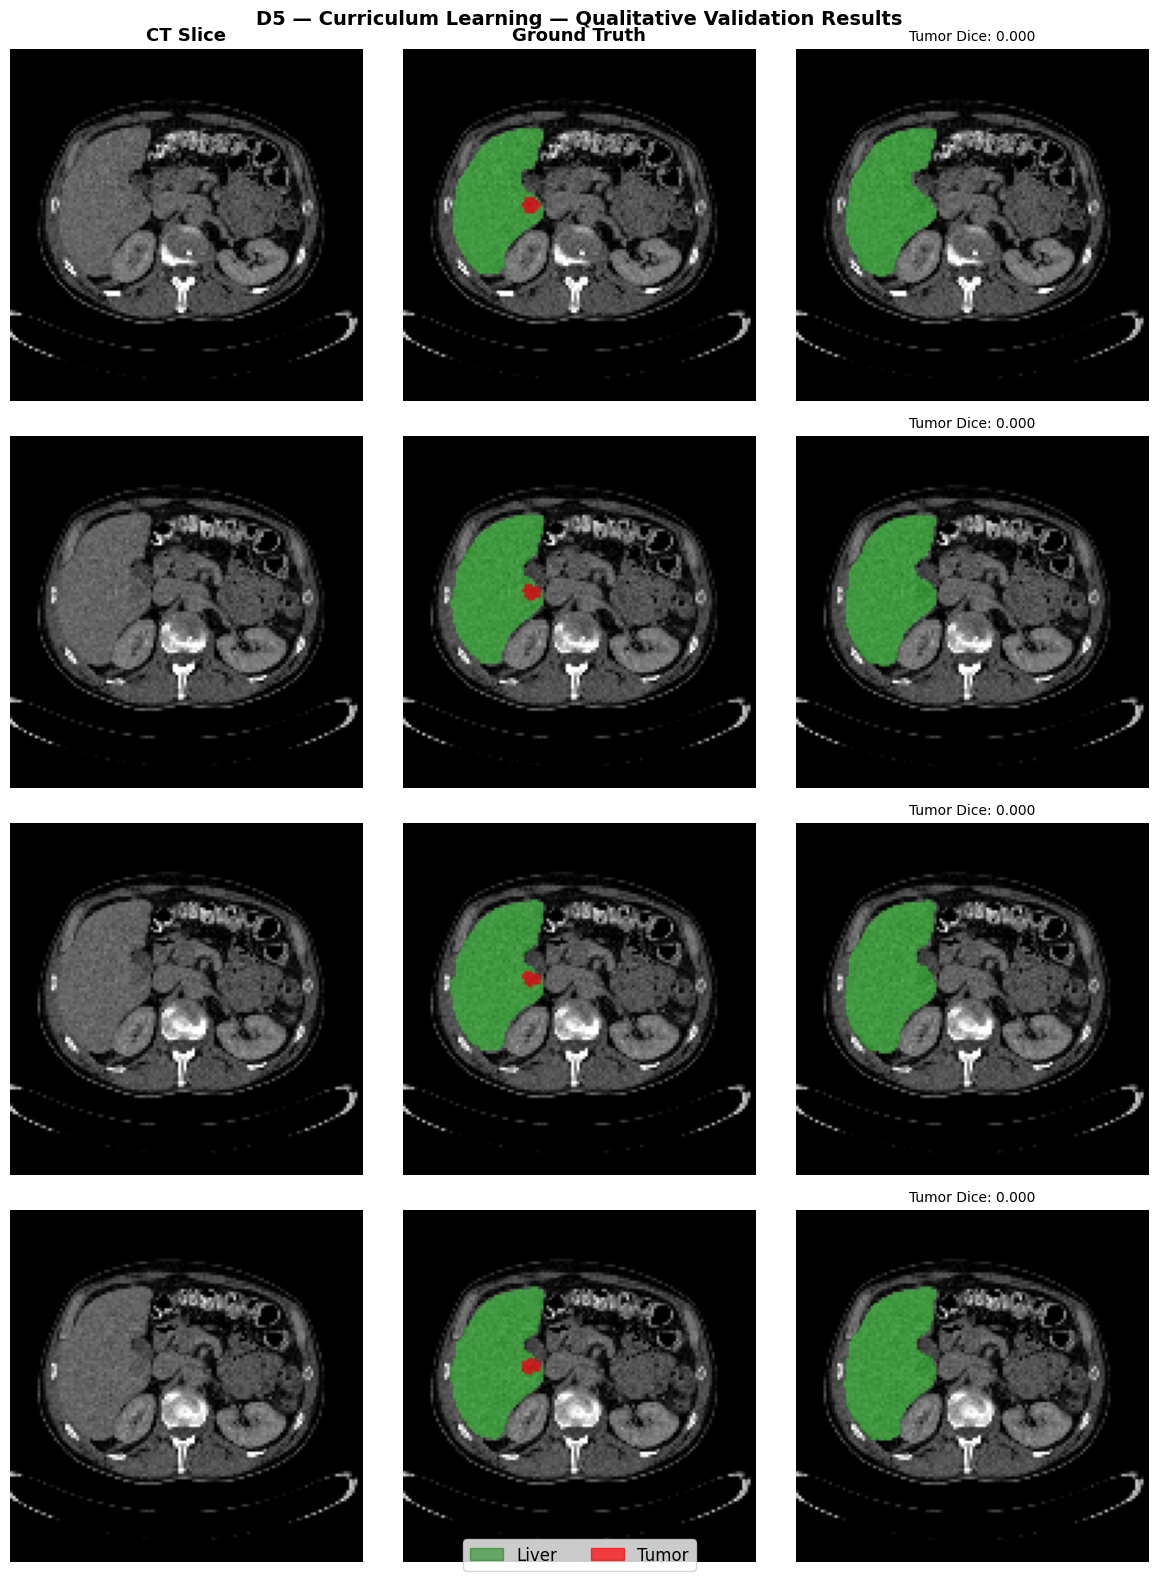

Saved: qualitative_d5.png


In [ ]:
model.eval()
samples = []

with torch.no_grad():
    for ct_batch, seg_batch in val_loader:
        ct_batch  = ct_batch.to(DEVICE)
        seg_batch = seg_batch.to(DEVICE)
        preds     = model(ct_batch)
        pred_cls  = preds.argmax(dim=1)

        for i in range(ct_batch.shape[0]):
            gt = seg_batch[i].cpu().numpy()
            if np.sum(gt == 2) > 30:
                samples.append({
                    'ct':   ct_batch[i, 0].cpu().numpy(),
                    'gt':   gt,
                    'pred': pred_cls[i].cpu().numpy()
                })
        if len(samples) >= 4:
            break

def make_overlay(ct, seg):
    overlay = np.zeros((*ct.shape, 4))
    overlay[seg == 1] = [0, 1, 0, 0.35]
    overlay[seg == 2] = [1, 0, 0, 0.65]
    return overlay

n_show = min(4, len(samples))
fig, axes = plt.subplots(n_show, 3, figsize=(12, 4 * n_show))
if n_show == 1: axes = [axes]

for col, title in enumerate(['CT Slice', 'Ground Truth', 'Prediction']):
    axes[0][col].set_title(title, fontsize=13, fontweight='bold')

for row, s in enumerate(samples[:n_show]):
    ct, gt, pred = s['ct'], s['gt'], s['pred']

    axes[row][0].imshow(ct.T, cmap='gray', origin='lower')
    axes[row][0].axis('off')

    axes[row][1].imshow(ct.T, cmap='gray', origin='lower')
    axes[row][1].imshow(make_overlay(ct, gt).transpose(1, 0, 2), origin='lower')
    axes[row][1].axis('off')

    axes[row][2].imshow(ct.T, cmap='gray', origin='lower')
    axes[row][2].imshow(make_overlay(ct, pred).transpose(1, 0, 2), origin='lower')

    p_t = (pred == 2).astype(float)
    g_t = (gt   == 2).astype(float)
    inter = (p_t * g_t).sum()
    denom = p_t.sum() + g_t.sum()
    sample_dice = (2 * inter / denom) if denom > 0 else 1.0
    axes[row][2].set_title(f'Tumor Dice: {sample_dice:.3f}', fontsize=10)
    axes[row][2].axis('off')

green_patch = mpatches.Patch(color='green', alpha=0.5, label='Liver')
red_patch   = mpatches.Patch(color='red',   alpha=0.7, label='Tumor')
fig.legend(handles=[green_patch, red_patch], loc='lower center', ncol=2, fontsize=12)
plt.suptitle('D5 — Curriculum Learning — Qualitative Validation Results',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('qualitative_d5.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: qualitative_d5.png')